# Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import json
import random
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

In [4]:
#Reading the txt file
with open("../data/HotelRec.txt", "r", encoding="utf-8", errors="ignore") as f:
    for i in range(10):
        print(f.readline())

{"hotel_url": "Hotel_Review-g194775-d1121769-Reviews-Hotel_Baltic-Giulianova_Province_of_Teramo_Abruzzo.html", "author": "violettaf340", "date": "2019-01-01T00:00:00", "rating": 5.0, "title": "Xmas holiday", "text": "We went here with our kids for Xmas holiday and we really liked it. Large options of food for breakfast and lunch , you can really taste the quality of the food in there. The surrounding area is nice and clean. Good experience. Hardly recommended .", "property_dict": {}}

{"hotel_url": "Hotel_Review-g194775-d1121769-Reviews-Hotel_Baltic-Giulianova_Province_of_Teramo_Abruzzo.html", "author": "Lagaiuzza", "date": "2016-01-01T00:00:00", "rating": 5.0, "title": "Baltic, what else?", "text": "We have spent in this hotel our summer holidays both in summer 2014 and 2015- I was with my husband and my child ( 4 years old at present). I do really recommend this place- Staff si high qualified, Kind and really helpful- Animation staff get You involved, but always with discrection - Mi

In [6]:
#Txt file taking too long to load, so creating a small 100k sample data to analyze the dataset for preprocessing
input_file = "../data/hotelrec.txt"
output_file = "../data/hotelrec_sample_100k.csv"

rows = []
limit = 100000

with open(input_file, "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if i >= limit:
            break

        obj = json.loads(line)

        props = obj.get("property_dict", {})

        rows.append({
            "hotel_id": obj.get("hotel_url"),
            "user_id": obj.get("author"),
            "date": obj.get("date"),
            "rating": obj.get("rating"),
            "title": obj.get("title"),
            "text": obj.get("text"),
            "service": props.get("service"),
            "location": props.get("location"),
            "value": props.get("value"),
            "cleanliness": props.get("cleanliness"),
            "rooms": props.get("rooms"),
            "sleep_quality": props.get("sleep quality"),
            "check_in": props.get("check in / front desk"),
            "business_service": props.get("business service (e.g., internet access)"),
            "ur_question.prompt.11": props.get("ur_question.prompt.11"),
            "userrating.prompt.190": props.get("userrating.prompt.190"),
            "userrating.prompt.46": props.get("userrating.prompt.46"),
            "userrating.prompt.48": props.get("userrating.prompt.48")
        })

df = pd.DataFrame(rows)
df.to_csv(output_file, index=False)

df.head()

,hotel_id,user_id,date,rating,title,text,service,location,value,cleanliness,rooms,sleep_quality,check_in,business_service,ur_question.prompt.11,userrating.prompt.190,userrating.prompt.46,userrating.prompt.48
0,Hotel_Review-g194775-d1121769-Reviews-Hotel_Ba...,violettaf340,2019-01-01T00:00:00,5.0,Xmas holiday,We went here with our kids for Xmas holiday an...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,Hotel_Review-g194775-d1121769-Reviews-Hotel_Ba...,Lagaiuzza,2016-01-01T00:00:00,5.0,"Baltic, what else?",We have spent in this hotel our summer holiday...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,Hotel_Review-g194775-d1121769-Reviews-Hotel_Ba...,ashleyn763,2014-10-01T00:00:00,5.0,Excellent in every way!,I visited Hotel Baltic with my husband for som...,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,Hotel_Review-g194775-d1121769-Reviews-Hotel_Ba...,DavideMauro,2014-08-01T00:00:00,5.0,The house of your family's holiday,I've travelled quite a numbers of hotels but t...,5.0,NaN,NaN,5.0,NaN,5.0,NaN,NaN,None,None,None,None
4,Hotel_Review-g194775-d1121769-Reviews-Hotel_Ba...,Alemma11,2013-08-01T00:00:00,4.0,"A paradise for children (and parents, of course)",We decided for this family holiday destination...,5.0,4.0,4.0,3.0,4.0,3.0,NaN,NaN,None,None,None,None


# Exploratory Data Analysis

In [7]:
print("Shape:", df.shape)

Shape: (100000, 18)


In [8]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['hotel_id', 'user_id', 'date', 'rating', 'title', 'text', 'service', 'location', 'value', 'cleanliness', 'rooms', 'sleep_quality', 'check_in', 'business_service', 'ur_question.prompt.11', 'userrating.prompt.190', 'userrating.prompt.46', 'userrating.prompt.48']


In [9]:
print("\nData types:")
print(df.dtypes)


Data types:
hotel_id                  object
user_id                   object
date                      object
rating                   float64
title                     object
text                      object
service                  float64
location                 float64
value                    float64
cleanliness              float64
rooms                    float64
sleep_quality            float64
check_in                 float64
business_service         float64
ur_question.prompt.11     object
userrating.prompt.190     object
userrating.prompt.46      object
userrating.prompt.48      object
dtype: object


In [10]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
hotel_id                      0
user_id                       0
date                          0
rating                        0
title                         0
text                          0
service                   28979
location                  49328
value                     47639
cleanliness               47462
rooms                     49186
sleep_quality             54614
check_in                  98099
business_service          98775
ur_question.prompt.11    100000
userrating.prompt.190    100000
userrating.prompt.46     100000
userrating.prompt.48     100000
dtype: int64


In [11]:
print("\nBasic rating statistics:")
print(df["rating"].describe())


Basic rating statistics:
count    100000.000000
mean          4.196580
std           1.062407
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64


## Aspect-rating data

In [12]:
#Checking if all the columns of the dataset are relevant or not.
aspect_cols = [
    "service",
    "location",
    "value",
    "cleanliness",
    "rooms",
    "sleep_quality",
    "check_in",
    "business_service",
    "ur_question.prompt.11",
    "userrating.prompt.190",
    "userrating.prompt.46",
    "userrating.prompt.48"
]

print("Aspect rating availability:")
for col in aspect_cols:
    if col in df.columns:
        available = df[col].notnull().sum()
        percentage = (available / len(df)) * 100
        print(f"{col}: {available} available ({percentage:.2f}%)")

Aspect rating availability:
service: 71021 available (71.02%)
location: 50672 available (50.67%)
value: 52361 available (52.36%)
cleanliness: 52538 available (52.54%)
rooms: 50814 available (50.81%)
sleep_quality: 45386 available (45.39%)
check_in: 1901 available (1.90%)
business_service: 1225 available (1.23%)
ur_question.prompt.11: 0 available (0.00%)
userrating.prompt.190: 0 available (0.00%)
userrating.prompt.46: 0 available (0.00%)
userrating.prompt.48: 0 available (0.00%)


## Understanding the users and hotels

In [13]:
#Understanding hotel and users data
print("Unique users:", df["user_id"].nunique())
print("Unique hotels:", df["hotel_id"].nunique())
print("Total reviews:", len(df))

print("\nAverage reviews per user:")
print(df.groupby("user_id").size().mean())

print("\nAverage reviews per hotel:")
print(df.groupby("hotel_id").size().mean())

Unique users: 93449
Unique hotels: 299
Total reviews: 100000

Average reviews per user:
1.0701024088005222

Average reviews per hotel:
334.44816053511704


In [14]:
user_reviews = df.groupby("user_id").size()

print(user_reviews.describe())

count    93449.000000
mean         1.070102
std          9.931791
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       3036.000000
dtype: float64


In [15]:
hotel_reviews = df.groupby("hotel_id").size()

print(hotel_reviews.describe())

count     299.000000
mean      334.448161
std       315.732354
min         6.000000
25%       119.500000
50%       266.000000
75%       444.500000
max      2219.000000
dtype: float64


In [16]:
print("\nTop 10 Hotels")

display(
    df.groupby("hotel_id")
      .size()
      .sort_values(ascending=False)
      .head(10)
)


Top 10 Hotels


hotel_id
Hotel_Review-g293916-d302770-Reviews-The_Sukhothai_Bangkok-Bangkok.html                                                              2219
Hotel_Review-g186338-d193058-Reviews-Days_Hotel_London_Waterloo-London_England.html                                                  2141
Hotel_Review-g154933-d182098-Reviews-Best_Western_Plus_Kelowna_Hotel_Suites-Kelowna_Okanagan_Valley_British_Columbia.html            1357
Hotel_Review-g616016-d1634559-Reviews-DoubleTree_by_Hilton_Resort_Zanzibar_Nungwi-Nungwi_Zanzibar_Island_Zanzibar_Archipelag.html    1356
Hotel_Review-g1905502-d633407-Reviews-Four_Seasons_Resort_Koh_Samui_Thailand-Ang_Thong_Ko_Samui_Surat_Thani_Province.html            1326
Hotel_Review-g3176298-d313883-Reviews-Tropical_Princess_Beach_Resort_Spa-Bavaro_Punta_Cana_La_Altagracia_Province_Dominican_.html    1322
Hotel_Review-g60945-d83182-Reviews-Murphy_s_Resort_at_Estes_Park-Estes_Park_Colorado.html                                            1262
Hotel_Review-g1204863-d78

### Rating Distribution Visualization

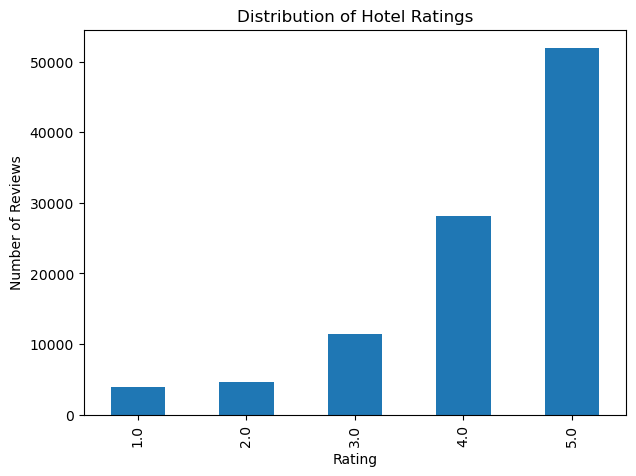

In [17]:
# Rating distribution
rating_counts = df["rating"].value_counts().sort_index()

plt.figure(figsize=(7,5))
rating_counts.plot(kind="bar")
plt.title("Distribution of Hotel Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

###

### Aspect Distribution Visualization

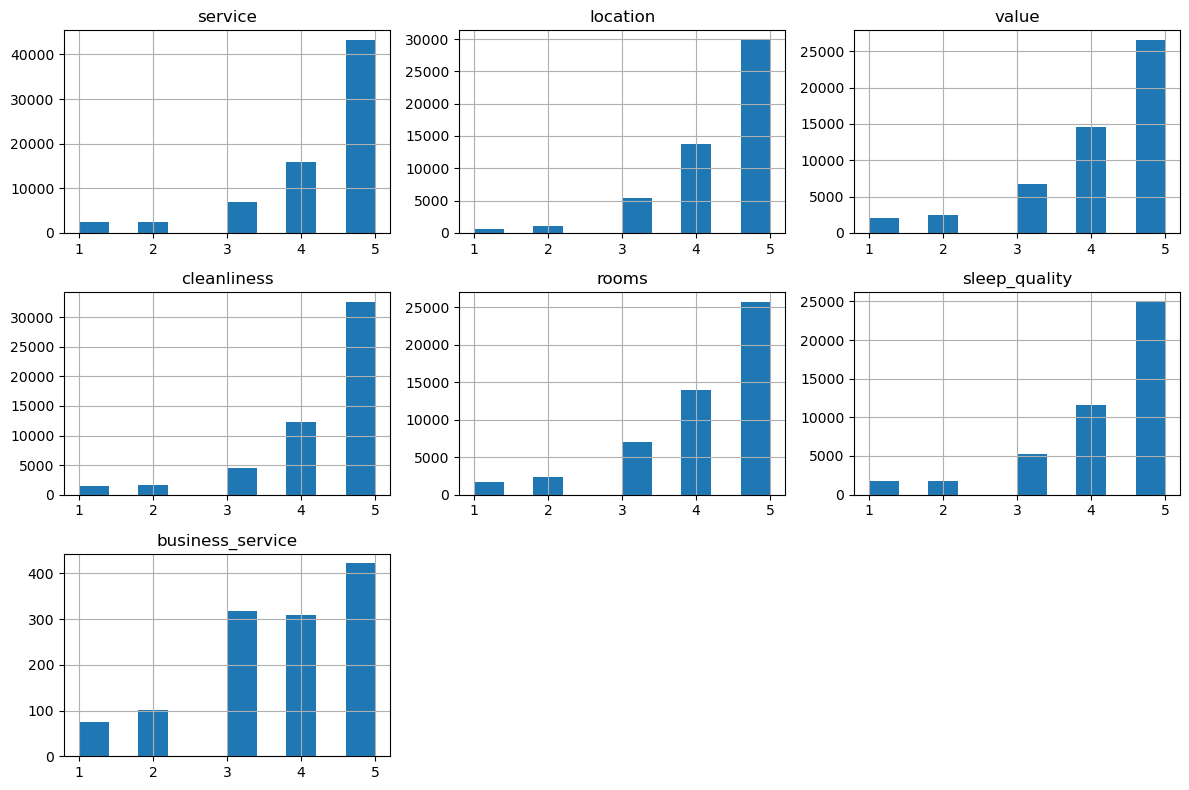

In [18]:
# Aspect Distribution
aspect_cols = [
    "service",
    "location",
    "value",
    "cleanliness",
    "rooms",
    "sleep_quality",
    "business_service",
]

df[aspect_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

### Correlation Data

In [19]:
#Checking for correlation between aspects
corr = df[aspect_cols + ["rating"]].corr()

corr

,service,location,value,cleanliness,rooms,sleep_quality,business_service,rating
service,1.000000,0.514122,0.726717,0.701858,0.695922,0.652607,0.579696,0.802078
location,0.514122,1.000000,0.548961,0.505001,0.510044,0.500010,0.374539,0.563668
value,0.726717,0.548961,1.000000,0.700820,0.729891,0.686224,0.594411,0.802496
cleanliness,0.701858,0.505001,0.700820,1.000000,0.790281,0.706692,0.570047,0.779511
rooms,0.695922,0.510044,0.729891,0.790281,1.000000,0.766885,0.580525,0.820413
sleep_quality,0.652607,0.500010,0.686224,0.706692,0.766885,1.000000,NaN,0.761959
business_service,0.579696,0.374539,0.594411,0.570047,0.580525,NaN,1.000000,0.613155
rating,0.802078,0.563668,0.802496,0.779511,0.820413,0.761959,0.613155,1.000000


In [21]:
#instead of the 100k rows, checking the data for random 200k rows which will better represent the diversity of hotels and users.
input_file = "../data/HotelRec.txt"

sample_size = 200000
sampling_rate = 0.004  

rows = []

with open(input_file, "r", encoding="utf-8") as f:
    for line in f:
        if random.random() < sampling_rate:
            obj = json.loads(line)

            props = obj.get("property_dict", {})

            rows.append({
                "hotel_id": obj.get("hotel_url"),
                "user_id": obj.get("author"),
                "rating": obj.get("rating"),
                "date": obj.get("date"),
                "title": obj.get("title"),
                "text": obj.get("text"),
                "service": props.get("service"),
                "location": props.get("location"),
                "value": props.get("value"),
                "sleep_quality": props.get("sleep quality"),
                "cleanliness": props.get("cleanliness"),
                "rooms": props.get("rooms"),
            })

            if len(rows) >= sample_size:
                break

df_random = pd.DataFrame(rows)

print(df_random.shape)
print(df_random["hotel_id"].nunique())
print(df_random["user_id"].nunique())

(200000, 12)
97812
192227


In [22]:
# Reviews per user
user_counts = df_random.groupby("user_id").size()

print(user_counts.describe())

print("\nUsers with exactly 1 review:")
print((user_counts == 1).sum())

print("\nUsers with 2 or more reviews:")
print((user_counts >= 2).sum())

print("\nUsers with 5 or more reviews:")
print((user_counts >= 5).sum())

print("\nUsers with 10 or more reviews:")
print((user_counts >= 10).sum())

count    192227.000000
mean          1.040437
std          10.636244
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        4663.000000
dtype: float64

Users with exactly 1 review:
189349

Users with 2 or more reviews:
2878

Users with 5 or more reviews:
3

Users with 10 or more reviews:
2


In [23]:
# Reviews per hotel
hotel_counts = df_random.groupby("hotel_id").size()

print(hotel_counts.describe())

print("\nHotels with at least 5 reviews:")
print((hotel_counts >= 5).sum())

print("\nHotels with at least 10 reviews:")
print((hotel_counts >= 10).sum())

print("\nHotels with at least 20 reviews:")
print((hotel_counts >= 20).sum())

count    97812.000000
mean         2.044739
std          2.447001
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         49.000000
dtype: float64

Hotels with at least 5 reviews:
6914

Hotels with at least 10 reviews:
1939

Hotels with at least 20 reviews:
349


In [24]:
#Reading the full 50gb file to count how many reviews each user and hotels has

input_file = "../data/HotelRec.txt"  

user_counts = Counter()
hotel_counts = Counter()
total_lines = 0
bad_lines = 0

with open(input_file, "r", encoding="utf-8", errors="ignore") as f:
    for line in tqdm(f, desc="Counting full dataset"):
        total_lines += 1
        
        try:
            obj = json.loads(line)
            user_id = obj.get("author")
            hotel_id = obj.get("hotel_url")
            
            if user_id and hotel_id:
                user_counts[user_id] += 1
                hotel_counts[hotel_id] += 1
            else:
                bad_lines += 1
                
        except Exception:
            bad_lines += 1

print("Total lines:", total_lines)
print("Bad lines:", bad_lines)
print("Unique users:", len(user_counts))
print("Unique hotels:", len(hotel_counts))

user_count_df = pd.DataFrame(user_counts.items(), columns=["user_id", "user_count"])
hotel_count_df = pd.DataFrame(hotel_counts.items(), columns=["hotel_id", "hotel_count"])

user_count_df.to_csv("../data/user_counts_full.csv", index=False)
hotel_count_df.to_csv("../data/hotel_counts_full.csv", index=False)

print("Saved user_counts_full.csv and hotel_counts_full.csv")

Counting full dataset: 50264531it [06:33, 127896.03it/s]


Total lines: 50264531
Bad lines: 0
Unique users: 21891404
Unique hotels: 365057
Saved user_counts_full.csv and hotel_counts_full.csv


In [26]:
#Checking for count distribution

user_count_df = pd.read_csv("../data/user_counts_full.csv")
hotel_count_df = pd.read_csv("../data/hotel_counts_full.csv")

print("User count statistics:")
print(user_count_df["user_count"].describe())

print("\nHotel count statistics:")
print(hotel_count_df["hotel_count"].describe())

print("\nUsers with 5+ reviews:", (user_count_df["user_count"] >= 5).sum())
print("Users with 10+ reviews:", (user_count_df["user_count"] >= 10).sum())

print("\nHotels with 5+ reviews:", (hotel_count_df["hotel_count"] >= 5).sum())
print("Hotels with 10+ reviews:", (hotel_count_df["hotel_count"] >= 10).sum())
print("Hotels with 20+ reviews:", (hotel_count_df["hotel_count"] >= 20).sum())

User count statistics:
count    2.189140e+07
mean     2.296085e+00
std      2.550637e+02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.193017e+06
Name: user_count, dtype: float64

Hotel count statistics:
count    365057.000000
mean        137.689542
std         342.943384
min           1.000000
25%          16.000000
50%          41.000000
75%         128.000000
max       10338.000000
Name: hotel_count, dtype: float64

Users with 5+ reviews: 2030354
Users with 10+ reviews: 699517

Hotels with 5+ reviews: 364991
Hotels with 10+ reviews: 326131
Hotels with 20+ reviews: 252437


# Final filtered CSV Dataset

In [29]:
#Creating a filtered dataset which contains only users with atleast 5 reviews and hotels with least 5 reviews,(System kept crashing so made it to write in chunks). This will also remove extremely sparse users and hotels.

input_file = "../data/HotelRec.txt"

user_count_df = pd.read_csv("../data/user_counts_full.csv")
hotel_count_df = pd.read_csv("../data/hotel_counts_full.csv")

valid_users = set(user_count_df.loc[user_count_df["user_count"] >= 5, "user_id"])
valid_hotels = set(hotel_count_df.loc[hotel_count_df["hotel_count"] >= 5, "hotel_id"])

print("Valid users:", len(valid_users))
print("Valid hotels:", len(valid_hotels))

output_file = "../data/hotelrec_5core_raw.csv"

rows = []
chunk_size = 200000
saved_rows = 0

with open(input_file, "r", encoding="utf-8", errors="ignore") as f:
    for line in tqdm(f, desc="Creating 5-core dataset"):
        obj = json.loads(line)

        user_id = obj.get("author")
        hotel_id = obj.get("hotel_url")

        if user_id in valid_users and hotel_id in valid_hotels:
            props = obj.get("property_dict", {})

            rows.append({
                "user_id": user_id,
                "hotel_id": hotel_id,
                "rating": obj.get("rating"),
                "date": obj.get("date"),
                "title": obj.get("title"),
                "text": obj.get("text"),
                "service": props.get("service"),
                "location": props.get("location"),
                "value": props.get("value"),
                "cleanliness": props.get("cleanliness"),
                "sleep_quality": props.get("sleep_quality"),
                "rooms": props.get("rooms")
            })

        if len(rows) >= chunk_size:
            pd.DataFrame(rows).to_csv(
                output_file,
                mode="a",
                index=False,
                header=(saved_rows == 0)
            )
            saved_rows += len(rows)
            rows = []

if rows:
    pd.DataFrame(rows).to_csv(
        output_file,
        mode="a",
        index=False,
        header=(saved_rows == 0)
    )
    saved_rows += len(rows)

print("Saved rows:", saved_rows)
print("Output file:", output_file)

Valid users: 2030354
Valid hotels: 364991


Creating 5-core dataset: 50264531it [14:05, 59471.24it/s] 


Saved rows: 22518482
Output file: ../data/hotelrec_5core_raw.csv


# Summary
1. Verified the dataset
2. Identified the useful features:
    - HotelID
    - UserID
    - Rating
    - title
    - text
    - date
    - service
    - location
    - value
    - cleanliness
    - rooms.
4. Identified the irrelevant features: Sleep quality, business service, check-in
5. Conducted data inspection, missing value analysis and some visualization in the initial 100K sample, data was very biased because the sample contained only 299 hotels.
6. Generated random sample of 200k reviews, which confirmed hotels and users are much more diverse which also gave a realization that user interactions are very sparse
7. Built a 5-core dataset which has users and hotels with 5 or more reviews.
8. Final dataset of:
    - Reviews: 22,518,482
    - Users: 2,030,354
    - Hotels: 364,991